## Main changes
- Implemented pydantic for both agents
- Set up schema repair agent
- Updated LangGraph for schema repair agents

# Config

In [1]:
from typing import TypedDict, List, Dict, Any
from langgraph.graph import StateGraph, START, END
import json
import os
import getpass
import re
from langchain_google_genai import ChatGoogleGenerativeAI
from pydantic import BaseModel, ValidationError
from pprint import pprint


import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))  

from schemas.query_check_blueprint import QueryCheckBlueprint
from schemas.planner_blueprint import PlannerBlueprint

In [2]:
if not os.environ.get("GOOGLE_API_KEY"):
    os.environ["GOOGLE_API_KEY"] = getpass.getpass("Enter your GOOGLE_API_KEY: ")

llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    temperature=0
)
model = ChatGoogleGenerativeAI(model="gemini-2.5-flash")
model_with_search = model.bind_tools([{"google_search": {}}])

Enter your GOOGLE_API_KEY:  ········


In [3]:
#response

In [4]:
#prompt = "hello world"
#response = llm.invoke(prompt)

In [5]:
#response

In [6]:
# print(response.content)

In [7]:
# from openai import OpenAI
# import os
# client = OpenAI(
#     api_key='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',
#     base_url="https://api.groq.com/openai/v1",
# )
#prompt = "hello world"
#response = client.responses.create(
#    input=prompt,
#    model="openai/gpt-oss-20b",
#)
#print(response.output_text)


# Agents


In [8]:
class State(TypedDict):
    graph_state: str
    user_input: str
 
    query_facts: Dict[str, Any]   # full QueryCheckBlueprint dump
    query_approved: bool
    query_attempts: int
    query_feedback: str
 
    plan: Dict[str, Any]
 
    schema_error: bool
    invalid_output: str # used for schema repair
    schema_name: str # used for schema repair
    is_repair_attempt: bool # flag: repaired output is ready
    query_json_attempts: int
    planner_json_attempts: int

In [9]:
def Schema_Repair_Agent(state: State) -> dict:
    broken_output = state.get("invalid_output")
    schema_name   = state.get("schema_name")
 
    if schema_name == "QueryCheckBlueprint":
        schema = QueryCheckBlueprint.model_json_schema()
    elif schema_name == "PlannerBlueprint":
        schema = PlannerBlueprint.model_json_schema()
    else:
        raise ValueError(f"Unknown schema_name: {schema_name!r}")
 
    repair_prompt = f"""You are a JSON repair assistant.
Your task is to fix invalid JSON so it strictly follows the required schema.
Rules:
- Return ONLY valid JSON.
- Do not add explanations.
- Retain all original information, do not change any information.
 
Schema Required:
{json.dumps(schema, indent=2)}
 
Broken Output:
{broken_output}
"""
    response = llm.invoke(repair_prompt)
    print(f"[Schema_Repair_Agent] Repaired output:\n{response.content[:300]}")
    return {
        "schema_error": False,
        "invalid_output": response.content,
        "schema_name": schema_name,   # preserve for next repair round
        "is_repair_attempt": True,
    }

In [10]:
def Query_Agent(state: State) -> dict:
    user_input = state.get("user_input")
    attempts  = state.get("query_attempts", 0)
    query_json_attempts = state.get("query_json_attempts", 0)
    repaired_output = state.get("invalid_output")
    print(f"[Query_Agent] is_repair_attempt={state.get('is_repair_attempt')}, query_json_attempts={query_json_attempts}")

    # Use repaired output if Schema_Repair_Agent just ran
    if state.get("is_repair_attempt") and repaired_output:
        raw_content = repaired_output
        print(f"[Query_Agent] Using repaired output:\n{raw_content[:300]}")
    else:
        query_check_prompt = f"""You are an expert fact-checking agent.
Your task is to analyse the details provided and identify factual claims.
 
Instructions:
1. Extract every fact from the details.
2. Check each fact for accuracy using reliable public sources.
3. Evaluate whether each fact is relevant to the occasion described.
4. If a fact refers to information that is unlikely to be publicly available, do NOT attempt to fact-check it. Mark it as supported = null.
5. Return ONLY valid JSON. Follow the output format strictly. Do not include explanations or text outside the JSON.
 
Details:
{user_input}
 
Output format:
{{
  "checks_results": [
    {{
      "serial_number": 1,
      "fact_identified": "<extracted factual claim>",
      "supported": <true | false | null>,
      "relevant": <true | false | null>,
      "source_url": "<URL used to verify the claim, or null if not checked>",
      "feedback": "<optional feedback>"
    }}
  ]
}}
"""
        response = model_with_search.invoke(query_check_prompt)
        print("FACT RAW RESPONSE")
        print(response.content)
        raw_content = extract_text_from_response(response.content)
        # if raw_content.startswith("```"):
        #     raw_content = "\n".join(raw_content.splitlines()[1:-1]).strip()
        print("raw_content")
        print(raw_content)
    try:
        facts = QueryCheckBlueprint.model_validate_json(raw_content)
        #print("FACTS")
        #print(facts)
    except ValidationError:
        return {
            "schema_error": True,
            "invalid_output": raw_content,
            "schema_name": "QueryCheckBlueprint",
            "is_repair_attempt": False,
            "query_json_attempts": query_json_attempts + 1,
        }
 
    query_approved = True
    feedback_list  = []
    for item in facts.checks_results:
        if item.supported is False or item.relevant is False:
            query_approved = False
            feedback_list.append(
                f"Fact: {item.fact_identified}\n"
                f"Supported: {item.supported}\n"
                f"Relevance: {item.relevant}\n"
                f"Feedback: {item.feedback or ''}"
            )
 
    return {
        "query_approved": query_approved,
        "query_feedback": "\n".join(feedback_list),
        "query_attempts": attempts + 1,
        "user_input": user_input,
        "query_facts": facts.model_dump(), 
        "invalid_output": None,
        "schema_error": False,
        "is_repair_attempt": False,
        "query_json_attempts": 0,                    # reset after success
    }

In [11]:
def Planner_Agent(state: State) -> dict:
    user_input = state.get("user_input")
    query_facts = state.get("query_facts")
    planner_json_attempts = state.get("planner_json_attempts", 0)
    repaired_output = state.get("invalid_output")
 
    # Use repaired output if Schema_Repair_Agent just ran
    if state.get("is_repair_attempt") and repaired_output:
        content = repaired_output
    else:
        planner_prompt = f"""You are an expert speech coach.
Your task:
1. Given verified speech details, produce a structured speech plan.
2. Facts that have undergone fact-checking should be placed under "must_include_facts". All other content should be placed under "must_include_points".
3. estimated_wpm must be between 120 and 150.
4. target_word_count must be calculated using: time_limit_minutes * estimated_wpm.
5. Return ONLY valid JSON. Follow the JSON structure strictly. Do not include explanations or text outside the JSON.
 
Speech Details:
{user_input}
 
Checked facts:
{query_facts}
 
JSON structure:
{{
  "request": {{
    "topic": "",
    "audience": "",
    "occasion": "",
    "time_limit_minutes": ""
  }},
  "targets": {{
    "estimated_wpm": "",
    "target_word_count": ""
  }},
  "sections": [
    {{
      "section_id": "S1",
      "name": "",
      "purpose": "",
      "must_include_points": [],
      "must_include_facts": []
    }}
  ]
}}
"""
        response = llm.invoke(planner_prompt)
        print("RAW PLAN OUTPUT:")
        print(response.content)
        content = extract_text_from_response(response.content)
        #if content.startswith("```"):
        #    content = "\n".join(content.splitlines()[1:-1]).strip()
 
    try:
        plan = PlannerBlueprint.model_validate_json(content)
        print("VALIDATED PLAN")
        pprint(plan.model_dump())
    except ValidationError:
        return {
            "schema_error": True,
            "invalid_output": content,
            "schema_name": "PlannerBlueprint",
            "is_repair_attempt": False,
            "planner_json_attempts": planner_json_attempts + 1,
        }
 

    return {
        "plan": plan.model_dump(),
        "invalid_output": None,
        "schema_error": False,
        "is_repair_attempt": False,
        "planner_json_attempts": 0,   # reset after success
    }

In [12]:
def collect_user_feedback(topic, audience, occasion, time_limit_in_minutes) -> str:
    revised_content = input("Revised Content to be included (i.e. Points, Examples and Facts): ").strip()
    return (
        f"Topic: {topic}\n"
        f"Audience: {audience}\n"
        f"Occasion: {occasion}\n"
        f"Time limit (in minutes): {time_limit_in_minutes}\n\n"
        f"Revised Content:\n{revised_content}"
    )

In [13]:
def Human_Feedback(state: State) -> dict:
    print("\n" + "=" * 50)
    print("FACT-CHECK FAILED — Amendment required")
    print("=" * 50)
    print(f"{state.get('query_feedback', 'No feedback provided.')}")
    print()
    print("Please re-enter your speech content with the issues fixed.")
 
    # Re-parse structured fields from the existing user_input string
    existing_input = state.get("user_input", "")
    parsed = {}
    for line in existing_input.splitlines():
        for key in ["Topic", "Audience", "Occasion", "Time limit (in minutes)"]:
            if line.startswith(f"{key}:"):
                parsed[key] = line[len(f"{key}:"):].strip()
 
    updated_input = collect_user_feedback(
        topic               = parsed.get("Topic", ""),
        audience            = parsed.get("Audience", ""),
        occasion            = parsed.get("Occasion", ""),
        time_limit_in_minutes = parsed.get("Time limit (in minutes)", ""),
    )
    return {
        "user_input": updated_input,
        "graph_state": updated_input,
        "query_approved": False,
        "query_feedback":    "",
        "invalid_output": None,
        "schema_error": False,
        "is_repair_attempt": False,
    }

In [14]:
def Approval_Router(state: State) -> State: # Passthrough node to allow two conditional edges out of Query_Agent
    return state

In [15]:
def extract_text_from_response(response_content) -> str: # Handles both plain string and list-of-parts responses from Gemini.
    if isinstance(response_content, list): # Join all string parts, skip non-string parts (e.g. tool results)
        text = "\n".join(
            part for part in response_content if isinstance(part, str)
        ).strip()
    else:
        text = response_content.strip()

    # Strip markdown code fences, remove opening fence (```json or ```) and closing fence (```)
    if text.startswith("```"):
        lines = text.splitlines()

        text = "\n".join(lines[1:-1] if lines[-1].strip() == "```" else lines[1:]).strip()

    return text

# Graph Set up 

In [16]:
def pydantic_query(state: State) -> str:
    attempts = state.get("query_json_attempts", 0)
    if attempts >= 3:
        raise ValueError(f"Query schema repair failed after {attempts} attempts")
    return "pydantic_failed" if state.get("schema_error", False) else "pydantic_passed"
 
 
def pydantic_planner(state: State) -> str:
    attempts = state.get("planner_json_attempts", 0)
    if attempts >= 3:
        raise ValueError(f"Planner schema repair failed after {attempts} attempts")
    return "pydantic_failed" if state.get("schema_error", False) else "pydantic_passed"
 
 
def route_user(state: State) -> str: # approver to planner or human feedback
    if state.get("query_approved"):
        return "approved"
    if state.get("query_attempts", 0) >= 2:
        # Max rejections reached — force through rather than looping forever
        raise ValueError("Query rejected too many times — aborting.")
    return "rejected"

In [17]:
builder = StateGraph(State)
 
builder.add_node("Query_Agent",               Query_Agent)
builder.add_node("Approval_Router",           Approval_Router)
builder.add_node("Human_Feedback",            Human_Feedback)
builder.add_node("Planner_Agent",             Planner_Agent)
builder.add_node("Query_Schema_Repair_Agent", Schema_Repair_Agent)
builder.add_node("Planner_Schema_Repair_Agent", Schema_Repair_Agent)
 
builder.add_edge(START, "Query_Agent")
 
builder.add_conditional_edges(
    "Query_Agent",
    pydantic_query,
    {
        "pydantic_passed": "Approval_Router",
        "pydantic_failed": "Query_Schema_Repair_Agent",
    }
)
 
builder.add_edge("Query_Schema_Repair_Agent", "Query_Agent")
 
builder.add_conditional_edges(
    "Approval_Router",
    route_user,
    {
        "approved": "Planner_Agent",
        "rejected": "Human_Feedback",
    }
)
 
builder.add_edge("Human_Feedback", "Query_Agent")
 
builder.add_conditional_edges(
    "Planner_Agent",
    pydantic_planner,
    {
        "pydantic_passed": END,
        "pydantic_failed": "Planner_Schema_Repair_Agent",
    }
)
 
builder.add_edge("Planner_Schema_Repair_Agent", "Planner_Agent")
 
graph = builder.compile()

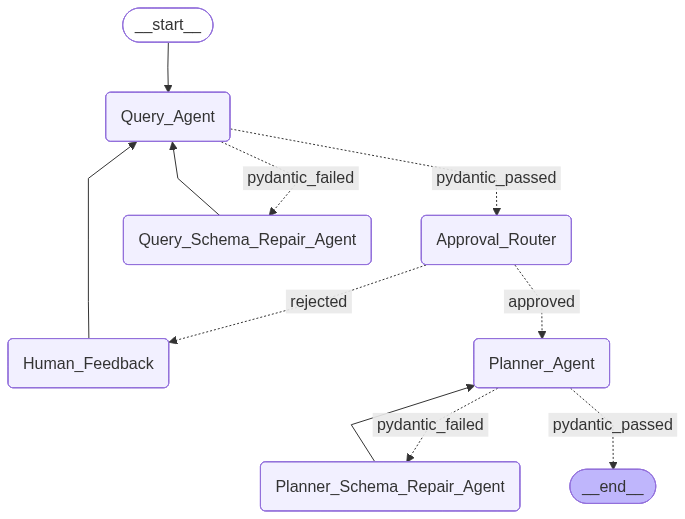

In [18]:
from IPython.display import Image, display
# View
display(Image(graph.get_graph().draw_mermaid_png()))

In [19]:
def collect_user_input() -> str:
    topic = input("Topic: ").strip()
    audience = input("Audience: ").strip()
    occasion = input("Occasion: ").strip()
    time_limit_in_minutes = input("Time limit (in minutes): ").strip()
    content = input("Content to be included (i.e. Points, Examples and Facts): ").strip()
    return (
        f"Topic: {topic}\n"
        f"Audience: {audience}\n"
        f"Occasion: {occasion}\n"
        f"Time limit (in minutes): {time_limit_in_minutes}\n\n"
        f"Content:\n{content}"
    )

In [ ]:
def main():
    print("Speech Generator ready. Type 'quit' at any prompt to exit.\n")
 
    while True:
        try:
            user_input = collect_user_input()
        except (KeyboardInterrupt, EOFError):
            print("\nGoodbye!")
            break
 
        if user_input.strip().lower() in ["quit", "exit", "q"]:
            print("Goodbye!")
            break
 
        if not user_input.strip():
            continue
 
        print("\nChecking your content...\n")
 
        initial_state: State = {
            "graph_state": user_input,
            "user_input": user_input,
            "query_facts": {},
            "query_approved": False,
            "query_attempts": 0,
            "query_feedback": "",
            "plan": {},
            "schema_error": False,
            "invalid_output": None,
            "schema_name": "",
            "is_repair_attempt": False,
            "query_json_attempts": 0,
            "planner_json_attempts": 0,
        }
 
        result = graph.invoke(initial_state)
 
        # Surface feedback if fact-check couldn't be resolved
        if not result.get("query_approved") and result.get("query_feedback"):
            print("\nNote: Some content could not be verified but the plan was generated anyway.")
            print(f"Feedback:\n{result['query_feedback']}\n")
 
        print("\n" + "=" * 50)
        print("YOUR SPEECH PLAN")
        print("=" * 50)
 
        plan = result.get("plan")
        if plan:
            pprint(plan) if isinstance(plan, dict) else print(plan)
        else:
            print("No plan generated.")
 
        again = input("\nGenerate another speech? (y/n): ").strip().lower()
        if again != "y":
            print("Goodbye!")
            break
 
 
if __name__ == "__main__":
    main()

Speech Generator ready. Type 'quit' at any prompt to exit.



Topic:  How Singapore can stay competitive by embracing Artificial Intelligence
Audience:  General public of Singaporeans
Occasion:  Singapore National Day Rally
Time limit (in minutes):  8
Content to be included (i.e. Points, Examples and Facts):  Theme 1: We are entering a new era with AI Points: None Facts: In 2020, AI struggled to solve basic math problems reliably, but by 2025 it could compete in the International Math Olympiad and achieve a gold medal-level performance. AI is already widely used by Singaporeans, including for travel planning where it can recommend destinations and generate personalised itineraries. In Singapore's civil service, AI is used in agency call centres to transcribe conversations in all four official languages and generate summaries so officers can focus on serving the public. Theme 2: We need to harness the potential of AI to raise productivity and create new value through every part of the economy, keeping our nation competitive Points: Singapore's abi


Checking your content...

[Query_Agent] is_repair_attempt=False, query_json_attempts=0
FACT RAW RESPONSE
['```json\n{\n  "checks_results": [\n    {\n      "serial_number": 1,\n      "fact_identified": "In 2020, AI struggled to solve basic math problems reliably, but by 2025 it could compete in the International Math Olympiad and achieve a gold medal-level performance.",\n      "supported": true,\n      "relevant": true,\n      "source_url": "https://vertexaisearch.cloud.google.com/grounding-api-redirect/AUZIYQEvauWGRB1njaqY8FEh-oJoFiEaaW561YarH5k23kr71r5nnGsslVOimEJ0zTLWpMWw9TIYCCCa0m-elI6iKrSJpwL2UsR-pZlqAqe3OatmTiwa7U_LmdV2x7SBxuzqFE2kT7cAUvpCTEpJXrA6Q57mVb5bVSLI6bIGRAK_rzoIep-2PKYPosh4cZmWfu2YbBsKPPwQ==, https://vertexaisearch.cloud.google.com/grounding-api-redirect/AUZIYQHSbBESBF_HCmryxewNRHLoVhQl2SvfOQianlyQJKmwjMKfmwLx_IDxVIW0z2hwR1NjHf-ctiVUQhGgd02neiRi-93xJXgiI7CZNFjNbJLh7HWJpZfmMnwzaPLPiUPLLH3XFmX_cJXrrZWf38msiM5kGqlTUpucbEcIv3I=, https://vertexaisearch.cloud.google.com/groun

## Theme 1: We are entering a new era with AI 
### Points: None 
### Facts: In 2020, AI struggled to solve basic math problems reliably, but by 2025 it could compete in the International Math Olympiad and achieve a gold medal-level performance. AI is already widely used by Singaporeans, including for travel planning where it can recommend destinations and generate personalised itineraries. In Singapore's civil service, AI is used in agency call centres to transcribe conversations in all four official languages and generate summaries so officers can focus on serving the public. 
## Theme 2: We need to harness the potential of AI to raise productivity and create new value through every part of the economy, keeping our nation competitive 
### Points: Singapore's ability to combine technology and human expertise attracts high-quality investments and creates good jobs. AI adoption is not limited to large companies, SMEs can also benefit. 
### Facts: AI is being combined with robotics and autonomous machines at Tuas Port and studied for automation at Changi Airport. GE Vernova's turbine repair facility in Singapore uses AI to detect anomalies in turbine components and alert human operators for precise diagnosis. SMEs like Q&M Dental use AI to analyse dental X-rays to help detect fillings, impacted teeth, and tooth decay more accurately. 
## Theme 3: Many people are concerned about job displacement due to AI, but there are opportunities from technological change 
### Points: Technological change in the past created disruption but also enabled workers to move into higher-skilled and better-paying jobs. 
### Facts: In the 1980s, Singapore launched a nationwide computerisation drive that equipped students and workers with computer skills and transformed the economy. When the internet arrived in the 1990s, Singapore successfully adopted it and propelled the nation forward. At PSA, crane operators were retrained to remotely supervise and manage multiple cranes and vehicles, boosting productivity and improving job quality. 
## Theme 4: Even as we embrace AI and technology, Singaporeans will always be our key priority 
### Points: The government will work closely with NTUC and unions to redesign jobs and equip workers with new skills. Efforts to help Singaporeans access jobs include expanded job matching services, more career fairs in tertiary institutions, and a new town-level job matching initiative led by CDCs. The SkillsFuture Level-Up Programme will expand to include more part-time training allowance claims and more courses from industry leaders and private training providers. 
### Facts: The SkillsFuture Level-Up Programme provides Singaporeans aged 40 and above with $4,000 in SkillsFuture credits and training allowances of up to $3,000 per month for up to 24 months for full-time study. Vinoth Nanda Kumaran, aged 41 in 2025, transitioned from private hire driver to Business Intelligence Developer after using SkillsFuture credits to pursue a diploma in data engineering and continuing his studies in Business Analytics at SUSS. 
## Theme 5: Embracing AI is in line with Singapore's broader strategy of building a dynamic, innovative economy that creates good jobs 
### Points: A dynamic economy is one that creates good jobs and better lives for all Singaporeans. Embracing AI supports Singapore's goal of staying globally competitive. Singapore aims to remain ahead through ideas, innovation, and unity. 
### Facts: None